<a href="https://colab.research.google.com/github/jahnavikrishnakancharla/-Lack-of-Access-to-Quality-Learning-Resources-/blob/main/Fertilizer_Recommendation_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# *MY FIRST **ML** PROJECT*
*   List item



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ==========================================================

# XGBoost is not installed by default in Colab
!pip install xgboost -q

In [3]:
# ==========================================================
# STEP 2: IMPORT ALL NECESSARY LIBRARIES
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data preprocessing
from sklearn.preprocessing import LabelEncoder

# Splitting dataset into training and testing
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Performance Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [5]:
# ==========================================================
# STEP 3: LOAD DATASET
# ==========================================================

# Upload CSV file manually in Google Colab

df = pd.read_csv("/content/archive (2).zip")

# Display first 5 rows
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [6]:
# ==========================================================
# STEP 4: EXPLORE THE DATASET
# ==========================================================

# Total rows and columns
print("Dataset Shape:")
print(df.shape)

print("\n")

# Dataset information
print("Dataset Information:")
print(df.info())

print("\n")

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape:
(99, 9)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      99 non-null     int64 
 1   Humidity         99 non-null     int64 
 2   Moisture         99 non-null     int64 
 3   Soil Type        99 non-null     object
 4   Crop Type        99 non-null     object
 5   Nitrogen         99 non-null     int64 
 6   Potassium        99 non-null     int64 
 7   Phosphorous      99 non-null     int64 
 8   Fertilizer Name  99 non-null     object
dtypes: int64(6), object(3)
memory usage: 7.1+ KB
None


Missing Values:
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64


In [7]:
# ==========================================================
# STEP 5: ENCODE CATEGORICAL VARIABLES
# ==========================================================

# Create Label Encoders

soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
fertilizer_encoder = LabelEncoder()

# Convert Soil Type into numbers
df['Soil Type'] = soil_encoder.fit_transform(df['Soil Type'])

# Convert Crop Type into numbers
df['Crop Type'] = crop_encoder.fit_transform(df['Crop Type'])

# Convert Fertilizer Name into numbers
df['Fertilizer Name'] = fertilizer_encoder.fit_transform(
    df['Fertilizer Name']
)

# Display transformed dataset
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,4,3,37,0,0,6
1,29,52,45,2,8,12,0,36,5
2,34,65,62,0,1,7,9,30,1
3,32,62,34,3,9,22,0,20,4
4,28,54,46,1,6,35,0,0,6


In [8]:
# ==========================================================
# STEP 6: SPLIT INPUTS AND OUTPUT
# ==========================================================

X = df.drop("Fertilizer Name", axis=1)

y = df["Fertilizer Name"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (99, 8)
Target Shape: (99,)


In [9]:
# ==========================================================
# STEP 7: TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,      # 20% Testing Data
    random_state=42      # Same results every time

)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (79, 8)
Testing Data: (20, 8)


In [10]:
# ==========================================================
# STEP 8: CREATE ALL ML MODELS
# ==========================================================

models = {

    "Random Forest":
    RandomForestClassifier(),

    "Support Vector Machine":
    SVC(),

    "K Nearest Neighbor":
    KNeighborsClassifier(),

    "Multi Layer Perceptron":
    MLPClassifier(max_iter=1000),

    "XGBoost":
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss'
    )

}

In [11]:
# ==========================================================
# STEP 9: TRAIN ALL MODELS
# ==========================================================

results = []

for model_name, model in models.items():

    print("\n")
    print("="*60)
    print("MODEL:", model_name)
    print("="*60)

    # Train Model
    model.fit(X_train, y_train)

    # Predict Test Data
    y_pred = model.predict(X_test)

    # Calculate Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Calculate Precision
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Calculate Recall
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Calculate F1 Score
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Store Results
    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))



MODEL: Random Forest
Accuracy : 0.95
Precision: 1.0
Recall   : 0.95
F1 Score : 0.9667


MODEL: Support Vector Machine
Accuracy : 0.9
Precision: 0.8667
Recall   : 0.9
F1 Score : 0.875


MODEL: K Nearest Neighbor
Accuracy : 0.9
Precision: 0.975
Recall   : 0.9
F1 Score : 0.9222


MODEL: Multi Layer Perceptron
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


MODEL: XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [12]:
# ==========================================================
# STEP 10: MODEL COMPARISON TABLE
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                    Model  Accuracy  Precision  Recall  F1 Score
4                 XGBoost      1.00   1.000000    1.00  1.000000
3  Multi Layer Perceptron      1.00   1.000000    1.00  1.000000
0           Random Forest      0.95   1.000000    0.95  0.966667
2      K Nearest Neighbor      0.90   0.975000    0.90  0.922222
1  Support Vector Machine      0.90   0.866667    0.90  0.875000


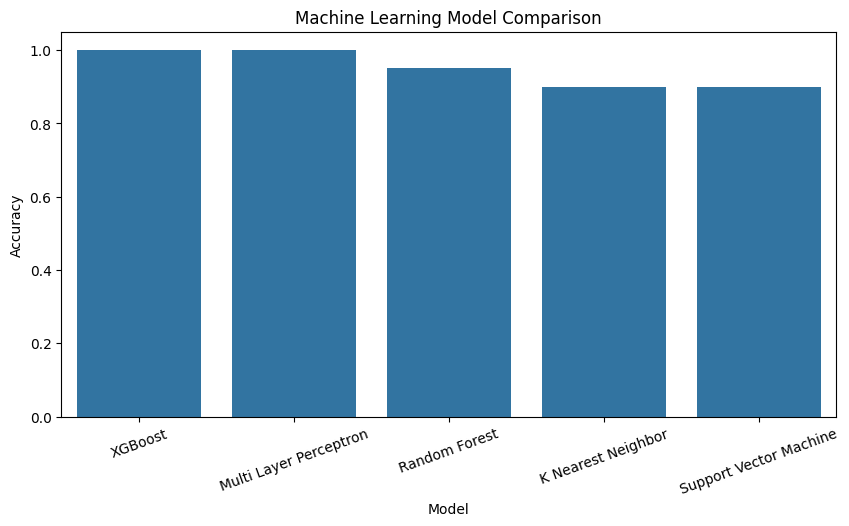

In [13]:
# ==========================================================
# STEP 11: VISUALIZE MODEL PERFORMANCE
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Machine Learning Model Comparison")

plt.xticks(rotation=20)

plt.show()

In [14]:
# ==========================================================
# STEP 12: TRAIN FINAL XGBOOST MODEL
# ==========================================================

from xgboost import XGBClassifier

# Create XGBoost model

best_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Train model

best_model.fit(X_train, y_train)

# Predict test data

y_pred = best_model.predict(X_test)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [15]:
# ==========================================================
# STEP 13: EVALUATE FINAL MODEL
# ==========================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("========== XGBOOST RESULTS ==========")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

========== XGBOOST RESULTS ==========
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


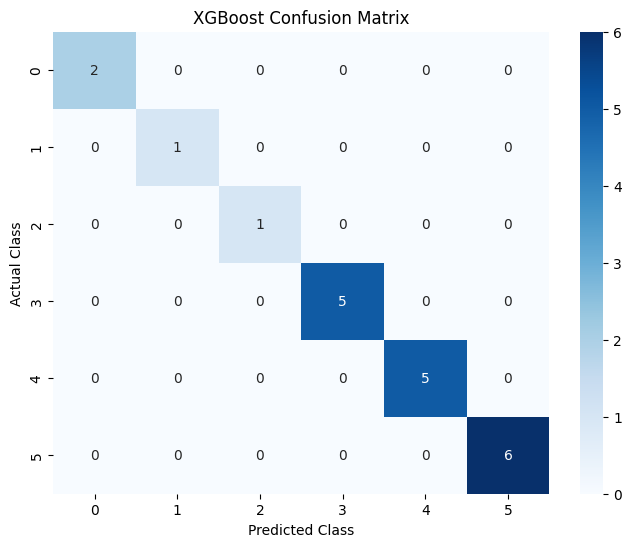

In [16]:
# ==========================================================
# STEP 14: CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

In [17]:
# ==========================================================
# STEP 15: FEATURE IMPORTANCE
# ==========================================================

feature_importance = best_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

       Feature  Importance
5     Nitrogen    0.402468
6    Potassium    0.363613
7  Phosphorous    0.226544
2     Moisture    0.004342
0  Temparature    0.002364
4    Crop Type    0.000669
3    Soil Type    0.000000
1    Humidity     0.000000


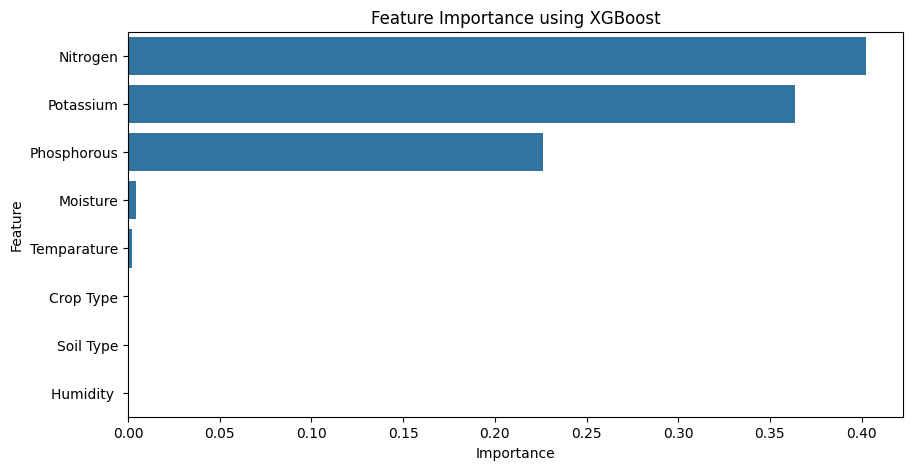

In [18]:
# ==========================================================
# STEP 16: VISUALIZE FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance using XGBoost")

plt.show()

In [19]:
# ==========================================================
# STEP 17: FERTILIZER PREDICTION
# ==========================================================

# Example Input

new_data = [[

    26,   # Temperature
    52,   # Humidity
    38,   # Moisture

    1,    # Soil Type
    3,    # Crop Type

    37,   # Nitrogen
    0,    # Phosphorous
    0     # Potassium

]]

prediction = best_model.predict(new_data)

fertilizer_name = fertilizer_encoder.inverse_transform(
    prediction
)

print("Recommended Fertilizer:")
print(fertilizer_name[0])

Recommended Fertilizer:
Urea


In [20]:
# ==========================================================
# STEP 18: SAVE MODEL
# ==========================================================

import joblib

joblib.dump(
    best_model,
    "xgboost_fertilizer_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
# ==========================================================
# STEP 19: DOWNLOAD MODEL
# ==========================================================

from google.colab import files

files.download(
    "xgboost_fertilizer_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>